In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/merged_data.csv")
df.shape

(36457, 19)

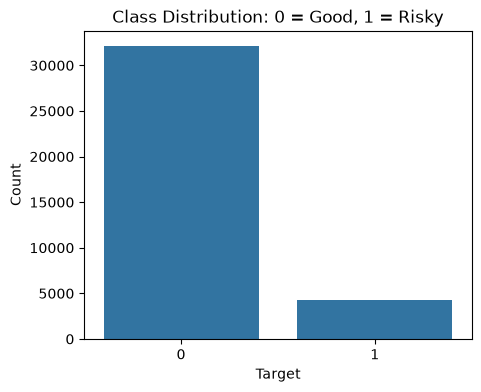

TARGET
0    88.22997
1    11.77003
Name: proportion, dtype: float64


In [2]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=df)
plt.title('Class Distribution: 0 = Good, 1 = Risky')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

print(df['TARGET'].value_counts(normalize=True) * 100)

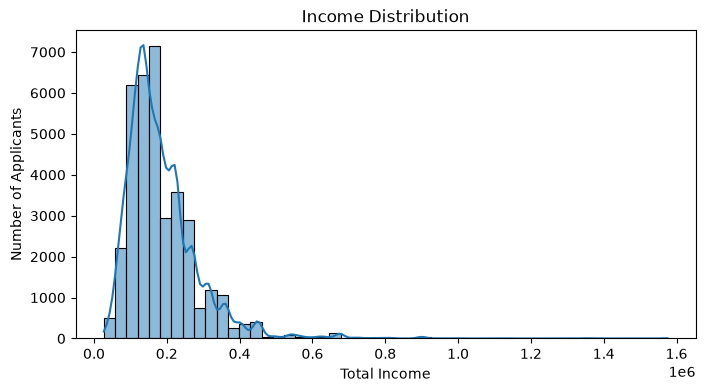

count    3.645700e+04
mean     1.866857e+05
std      1.017892e+05
min      2.700000e+04
25%      1.215000e+05
50%      1.575000e+05
75%      2.250000e+05
max      1.575000e+06
Name: AMT_INCOME_TOTAL, dtype: float64


In [3]:
plt.figure(figsize=(8,4))
sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Income Distribution')
plt.xlabel('Total Income')
plt.ylabel('Number of Applicants')
plt.show()

print(df['AMT_INCOME_TOTAL'].describe())


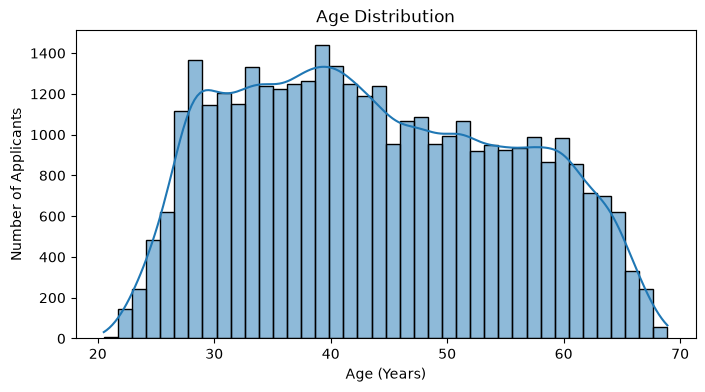

count    36457.000000
mean        43.767598
std         11.508356
min         20.517808
25%         34.142466
50%         42.638356
75%         53.254795
max         68.909589
Name: AGE_YEARS, dtype: float64


In [4]:
df['AGE_YEARS'] = (-df['DAYS_BIRTH']) / 365

plt.figure(figsize=(8,4))
sns.histplot(df['AGE_YEARS'], bins=40, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Applicants')
plt.show()

print(df['AGE_YEARS'].describe())

count     36457.000000
mean      59262.935568
std      137651.334859
min      -15713.000000
25%       -3153.000000
50%       -1552.000000
75%        -408.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


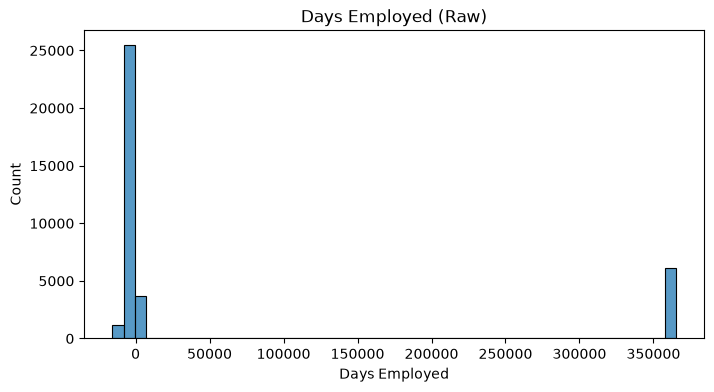

In [5]:
print(df['DAYS_EMPLOYED'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['DAYS_EMPLOYED'], bins=50)
plt.title('Days Employed (Raw)')
plt.xlabel('Days Employed')
plt.ylabel('Count')
plt.show()

In [6]:
# Flag applicants with the placeholder unemployment code
df['IS_UNEMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# Replace placeholder with 0 (no active employment duration)
df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, 0)

# Convert to years employed (only meaningful for employed people)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED_CLEAN']) / 365
df.loc[df['IS_UNEMPLOYED'] == 1, 'YEARS_EMPLOYED'] = 0

print(df['IS_UNEMPLOYED'].value_counts())
print(df['YEARS_EMPLOYED'].describe())

IS_UNEMPLOYED
0    30322
1     6135
Name: count, dtype: int64
count    36457.000000
mean         6.028266
std          6.484375
min          0.000000
25%          1.117808
50%          4.252055
75%          8.638356
max         43.049315
Name: YEARS_EMPLOYED, dtype: float64


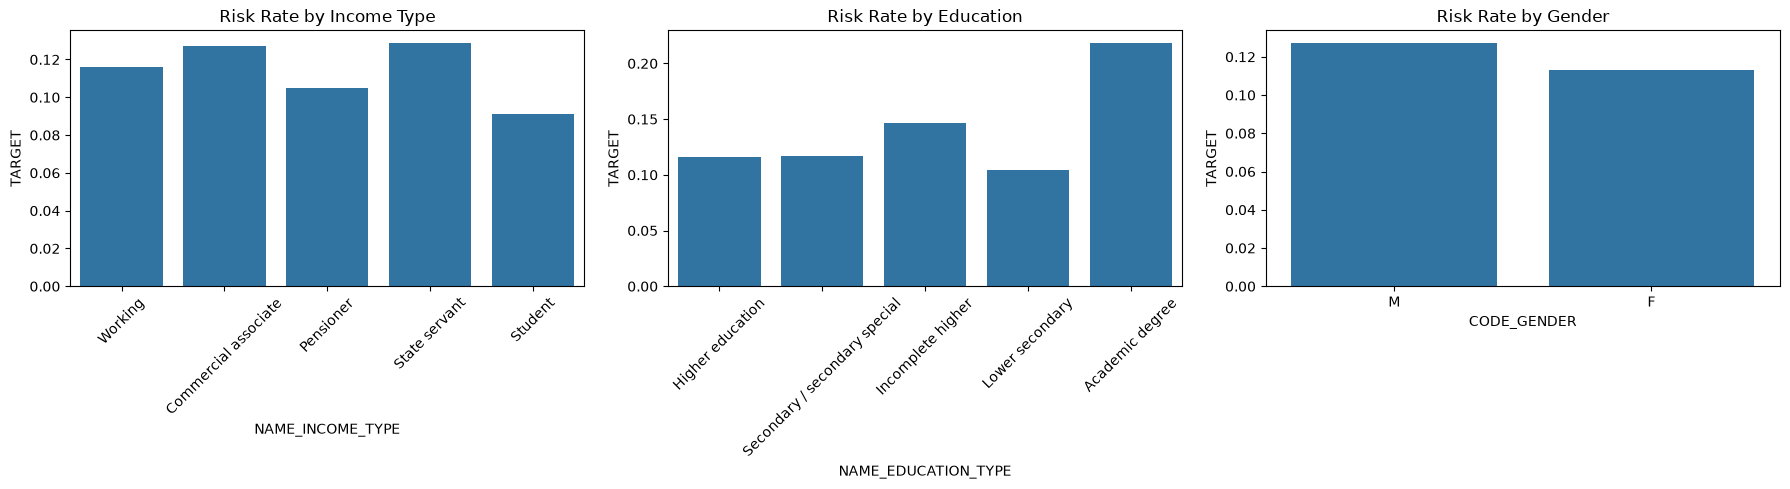

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.barplot(x='NAME_INCOME_TYPE', y='TARGET', data=df, ax=axes[0], errorbar=None)
axes[0].set_title('Risk Rate by Income Type')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x='NAME_EDUCATION_TYPE', y='TARGET', data=df, ax=axes[1], errorbar=None)
axes[1].set_title('Risk Rate by Education')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(x='CODE_GENDER', y='TARGET', data=df, ax=axes[2], errorbar=None)
axes[2].set_title('Risk Rate by Gender')

plt.tight_layout()
plt.show()

In [8]:
print(df['NAME_INCOME_TYPE'].value_counts())
print()
print(df['NAME_EDUCATION_TYPE'].value_counts())

NAME_INCOME_TYPE
Working                 18819
Commercial associate     8490
Pensioner                6152
State servant            2985
Student                    11
Name: count, dtype: int64

NAME_EDUCATION_TYPE
Secondary / secondary special    24777
Higher education                  9864
Incomplete higher                 1410
Lower secondary                    374
Academic degree                     32
Name: count, dtype: int64


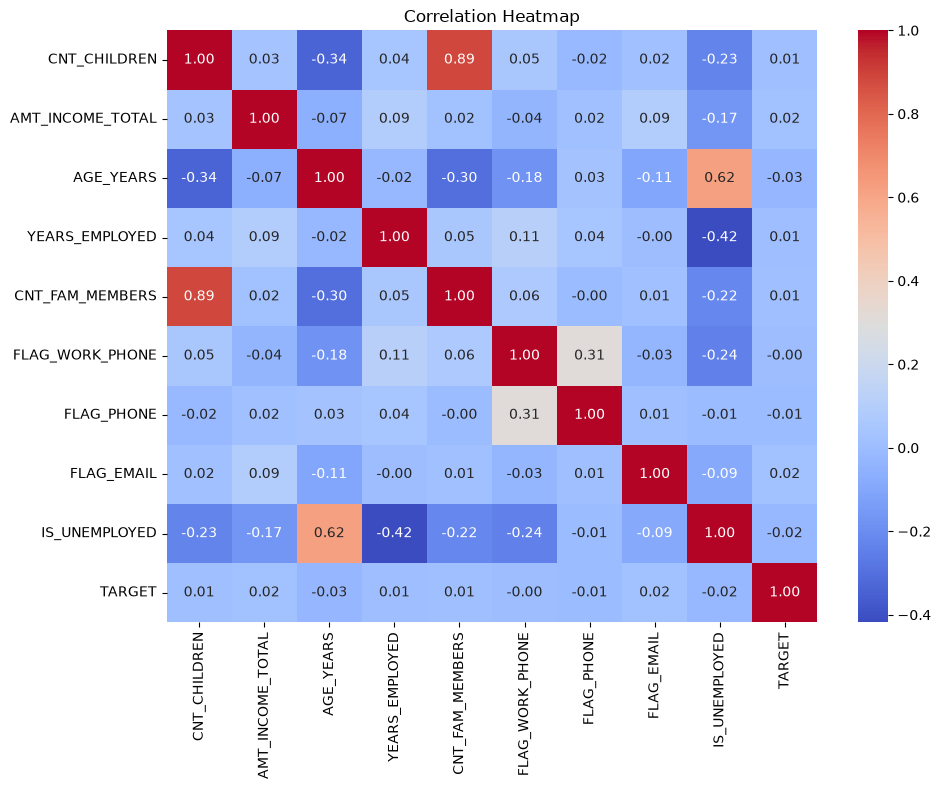

In [9]:
numeric_cols = ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AGE_YEARS', 'YEARS_EMPLOYED', 
                 'CNT_FAM_MEMBERS', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 
                 'IS_UNEMPLOYED', 'TARGET']

plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()